# Retinal Vessel Segmentation: Train Multiple Models on Diverse Pairs

This notebook first selects the most diverse training pairs based on image and mask features, then trains a separate U-Net on each of these pairs. The best model (highest Dice on the test set) is identified for potential use.

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import time
import os
import random

from PIL import Image
import copy
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.utils.data as data
import torchvision
import torchvision.transforms as T

import math
import cv2
from pathlib import Path

import skimage
from skimage.measure import label, regionprops
from skimage import morphology
import torchvision.models as models
from scipy.spatial.distance import pdist, squareform

print("All imports successful.")

All imports successful.


## Dataset Class

Loads images, LIOT features, and ground truth masks.

In [52]:
class ImageDataset(data.Dataset):
    def __init__(self, root, new_size=592, supervised=True):
        self.root = Path(root)
        self.supervised = supervised

        self.image_paths = sorted(self.root.rglob('*.tif*'))  # matches .tif or .tiff
        self.image_liot_eg_paths = sorted(self.root.rglob('*liot_eg*.npy'))
        if self.supervised:
            self.label_paths = sorted(list(self.root.rglob('*.gif')) + list(self.root.rglob('*.png')))

        # --- DEBUG PRINTS ---
        print(f"Dataset root: {root}")
        print(f"  Images found: {len(self.image_paths)}")
        if self.image_paths:
            print(f"  First 5 images: {[p.name for p in self.image_paths[:5]]}")
        print(f"  LIOT features found: {len(self.image_liot_eg_paths)}")
        if self.image_liot_eg_paths:
            print(f"  First 5 LIOT files: {[p.name for p in self.image_liot_eg_paths[:5]]}")
        if self.supervised:
            print(f"  Labels found: {len(self.label_paths)}")
            if self.label_paths:
                print(f"  First 5 labels: {[p.name for p in self.label_paths[:5]]}")
        # --------------------

        self.new_size = new_size
        self.imagesize = None

    def borders(self, original_size):
        """
        Compute padding for target size
        """
        H, W = original_size
        delta_h = max(self.new_size - H, 0)
        delta_w = max(self.new_size - W, 0)

        top    = delta_h // 2
        bottom = delta_h - top
        left   = delta_w // 2
        right  = delta_w - left

        return left, top, right, bottom

    def __getitem__(self, index):

        image_path = self.image_paths[index]
        image = Image.open(image_path)
        image_liot_eg_path = self.image_liot_eg_paths[index]
        image_liot_eg = np.load(image_liot_eg_path)

        if self.supervised:
            label_path = self.label_paths[index]
            label = Image.open(label_path)

        self.imagesize = np.shape(image)[0:2]

        transform = []
        transform.append(T.ToTensor())
        transform.append(T.Pad(
            self.borders(self.imagesize))
        )
        transform = T.Compose(transform)
        image = transform(image)
        image_liot_eg = transform(image_liot_eg.transpose(1, 2, 0))

        if self.supervised:
            label = transform(label)
            return image, image_liot_eg, label

        return image, image_liot_eg

    def __len__(self):
        return len(self.image_paths)

## Load Data

Dataset root: E:\work\pfe_work\code\Hessian-based Deep Retinal Vessel Segmentation with Extremely Few Annotations\prepared data\test_data
  Images found: 20
  First 5 images: ['01_test.tiff', '02_test.tiff', '03_test.tiff', '04_test.tiff', '05_test.tiff']
  LIOT features found: 20
  First 5 LIOT files: ['01_test_liot_eg.npy', '02_test_liot_eg.npy', '03_test_liot_eg.npy', '04_test_liot_eg.npy', '05_test_liot_eg.npy']
  Labels found: 20
  First 5 labels: ['01_test_mask.png', '02_test_mask.png', '03_test_mask.png', '04_test_mask.png', '05_test_mask.png']
Dataset root: E:\work\pfe_work\code\Hessian-based Deep Retinal Vessel Segmentation with Extremely Few Annotations\prepared data\train_data_s
  Images found: 20
  First 5 images: ['21_training.tiff', '22_training.tiff', '23_training.tiff', '24_training.tiff', '25_training.tiff']
  LIOT features found: 20
  First 5 LIOT files: ['21_training_liot_eg.npy', '22_training_liot_eg.npy', '23_training_liot_eg.npy', '24_training_liot_eg.npy', '25_tr

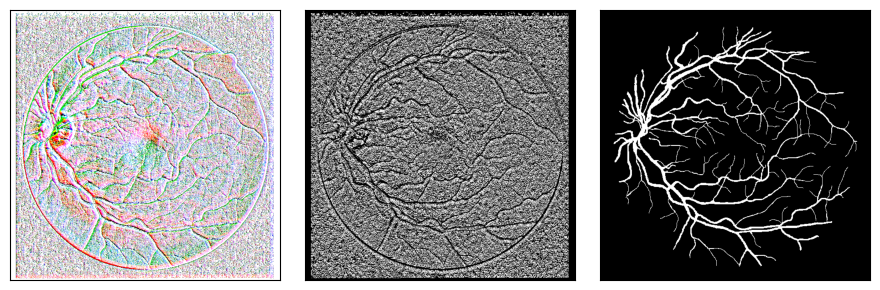

In [53]:
root = r"E:\work\pfe_work\code\Hessian-based Deep Retinal Vessel Segmentation with Extremely Few Annotations\prepared data"
test_dataset = ImageDataset(root = os.path.join(root,'test_data'))
train_dataset_supervised = ImageDataset(root = os.path.join(root,'train_data_s'))

train_dataloader_supervised = data.DataLoader(train_dataset_supervised, shuffle = True, batch_size= 2)
test_dataloader = data.DataLoader(test_dataset, shuffle = False, batch_size = 1)

dataloaders = {'train supervised' : train_dataloader_supervised,  'test' : test_dataloader}
dataset_sizes = {'train supervised' : len(train_dataset_supervised),'test' : len(test_dataset)}
batch_sizes =  {'train supervised' : 2, 'test' : 1}
print("Dataset sizes: ", dataset_sizes)

it = iter(dataloaders['test'])
inputs, inputs_LIOT_eg, labels = next(it)
print("original size: ", test_dataset.imagesize)
original_size = T.CenterCrop(test_dataset.imagesize)
out_inputs = torchvision.utils.make_grid(inputs)
out_LIOT_eg_inputs = torchvision.utils.make_grid(inputs_LIOT_eg)
out_labels = torchvision.utils.make_grid(labels)

fig,axes = plt.subplots(1,3,figsize=(9,3))
axes[0].imshow(out_inputs.permute(1,2,0))
axes[0].set_xticks([])
axes[0].set_yticks([])
axes[1].imshow(out_LIOT_eg_inputs[0], cmap = "gray")
axes[1].set_xticks([])
axes[1].set_yticks([])
axes[2].imshow(out_labels.permute(1,2,0))
axes[2].set_xticks([])
axes[2].set_yticks([])
fig.tight_layout()
plt.show()

## U-Net Architecture

In [32]:
class DoubleConv(nn.Module):
    """
    Apply two 3×3 convolutions (padding=1), batch normalization and ReLU.
    """
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.doubleconv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.doubleconv(x)


class Down(nn.Module):
    """
    Apply 2×2 max pooling, then double convolution.
    """
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.downconv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels)
        )

    def forward(self, x):
        return self.downconv(x)


class Up(nn.Module):
    """
    Apply a transposed convolution for upsampling, then double convolution.
    """
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, in_channels // 2, kernel_size=2, stride=2)
        self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x1, x2):
        x1 = self.up(x1)
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)


# ---------------------------------------------------------------------------
# Morpho-U-Net  (Paulauskaite-Taraseviciene et al., J. Clin. Med. 2025)
# ---------------------------------------------------------------------------

class MorphoPreprocessor(nn.Module):
    """
    Differentiable morphological preprocessing block.

    Implements the four-step pipeline described in the paper:
      1. Gaussian blur       - smooths the input to reduce noise.
      2. Soft thresholding   - produces a differentiable binary-like mask
                               (sigmoid centred on `threshold`, steepness=20).
      3. Morphological opening  (erosion -> dilation)
                             - removes isolated small-noise pixels.
      4. Morphological closing  (dilation -> erosion)
                             - fills gaps and makes vessel structures continuous.

    Erosion  is approximated by  -max_pool(-x).
    Dilation is approximated by   max_pool( x).
    Both are fully differentiable, so gradients flow through the preprocessor.

    Args:
        in_channels  : number of input feature channels (applied depth-wise).
        gauss_kernel : side length of the square Gaussian kernel (odd int).
        gauss_sigma  : standard deviation of the Gaussian kernel.
        morph_kernel : side length of the square structuring element (odd int).
        threshold    : centre of the sigmoid soft-threshold (default 0.47,
                       matching the value used in Algorithm 1 of the paper).
    """

    def __init__(self, in_channels, gauss_kernel=5, gauss_sigma=1.0,
                 morph_kernel=3, threshold=0.47):
        super().__init__()
        self.in_channels  = in_channels
        self.morph_kernel = morph_kernel
        self.morph_pad    = morph_kernel // 2
        self.threshold    = threshold
        self.gauss_pad    = gauss_kernel // 2

        # Pre-compute Gaussian kernel and register as a non-trainable buffer.
        gauss = self._make_gaussian_kernel(gauss_kernel, gauss_sigma)
        # Expand to (in_channels, 1, k, k) for depth-wise convolution.
        self.register_buffer('gauss', gauss.expand(in_channels, 1, -1, -1).contiguous())

    @staticmethod
    def _make_gaussian_kernel(k, sigma):
        ax = torch.linspace(-(k - 1) / 2., (k - 1) / 2., k)
        xx, yy = torch.meshgrid(ax, ax, indexing='ij')
        kernel = torch.exp(-0.5 * (xx ** 2 + yy ** 2) / sigma ** 2)
        return (kernel / kernel.sum()).view(1, 1, k, k)  # (1,1,k,k)

    # -- morphological primitives --------------------------------------------

    def _dilate(self, x):
        """Morphological dilation via max-pool."""
        return F.max_pool2d(x, self.morph_kernel, stride=1, padding=self.morph_pad)

    def _erode(self, x):
        """Morphological erosion via negated max-pool."""
        return -F.max_pool2d(-x, self.morph_kernel, stride=1, padding=self.morph_pad)

    def _opening(self, x):
        """Morphological opening: erosion followed by dilation."""
        return self._dilate(self._erode(x))

    def _closing(self, x):
        """Morphological closing: dilation followed by erosion."""
        return self._erode(self._dilate(x))

    # -- forward pass --------------------------------------------------------

    def forward(self, x):
        # Step 1 - Gaussian blur (depth-wise, one kernel per channel)
        blurred = F.conv2d(x, self.gauss, padding=self.gauss_pad,
                           groups=self.in_channels)

        # Step 2 - Soft threshold  (differentiable approximation of binarisation)
        soft_mask = torch.sigmoid(20.0 * (blurred - self.threshold))

        # Step 3 - Morphological opening  (remove small noise)
        opened = self._opening(soft_mask)

        # Step 4 - Morphological closing  (fill gaps, continuous vessels)
        closed = self._closing(opened)

        return closed   # same shape as x


class MorphoUNet(nn.Module):
    """
    Morpho-U-Net: standard U-Net with an integrated morphological
    preprocessing block, as described in:

        Paulauskaite-Taraseviciene et al.
        'A Robust Blood Vessel Segmentation Technique for Angiographic
        Images Employing Multi-Scale Filtering Approach'
        J. Clin. Med. 2025, 14, 354.

    Architecture:
        The MorphoPreprocessor runs in parallel with the raw input.
        Its output (morphologically cleaned feature maps, same spatial size
        and channel count as x) is concatenated with the raw input along the
        channel axis.  The resulting 2*in_channels tensor is fed into the
        standard U-Net encoder, giving the network access to both the
        original signal and the noise-suppressed, vessel-enhanced maps.

    Args:
        in_channels  : number of raw input channels.
        gauss_kernel : Gaussian blur kernel size (default 5).
        gauss_sigma  : Gaussian blur sigma       (default 1.0).
        morph_kernel : structuring element size  (default 3).
        threshold    : soft-threshold centre     (default 0.47).
    """

    def __init__(self, in_channels, gauss_kernel=5, gauss_sigma=1.0,
                 morph_kernel=3, threshold=0.47):
        super().__init__()

        self.preprocessor = MorphoPreprocessor(
            in_channels, gauss_kernel, gauss_sigma, morph_kernel, threshold
        )

        # The encoder receives raw + morpho channels concatenated.
        enc_in = in_channels * 2

        # -- Encoder --
        self.inc   = DoubleConv(enc_in, 64)
        self.down1 = Down(64,   128)
        self.down2 = Down(128,  256)
        self.down3 = Down(256,  512)
        self.down4 = Down(512, 1024)

        # -- Decoder --
        self.up1 = Up(1024, 512)
        self.up2 = Up(512,  256)
        self.up3 = Up(256,  128)
        self.up4 = Up(128,   64)

        # -- Output head --
        self.out = nn.Conv2d(64, 1, kernel_size=1)

    def forward(self, x):
        # Morphological preprocessing
        morpho = self.preprocessor(x)           # (B, C, H, W)

        # Concatenate raw input and morpho-processed features
        x_in = torch.cat([x, morpho], dim=1)    # (B, 2C, H, W)

        # U-Net encoder
        x1 = self.inc(x_in)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)

        # U-Net decoder with skip connections
        x  = self.up1(x5, x4)
        x  = self.up2(x,  x3)
        x  = self.up3(x,  x2)
        x  = self.up4(x,  x1)

        return self.out(x)


## CLAHE Preprocessing

In [33]:
def clahe(inputs, clipLimit=4, tileGridSize=(8,8)):
    """
    Compute CLAHE for green channel of inputs.
    """
    inputs = inputs.to('cpu')
    clahe = cv2.createCLAHE(clipLimit=clipLimit, tileGridSize=tileGridSize)
    green_channel = np.uint8(255 * inputs[:,1,:,:])
    res = np.array([clahe.apply(i) for i in green_channel], dtype=float) / 255
    res = torch.tensor(res, dtype=torch.float).unsqueeze(1)
    return res.to(device)

## Boundary-Loss (BZ_Loss)

In [34]:
class BZ_Loss(nn.Module):

    def __init__(self, config_loss = 0, config_bz = 0):

        super(BZ_Loss, self).__init__()
        self.Gx = torch.tensor(([-1,0,1],[-2,0,2],[-1,0,1]), dtype = torch.float)
        self.Gy = torch.tensor(([1,2,1],[0,0,0],[-1,-2,-1]), dtype = torch.float)
        self.RGB_to_GRAY = T.Grayscale()
        self.config_loss = config_loss
        self.config_bz = config_bz

    def gaussian_kernel(self, kernel_size, sigma):
        """
        Return a gaussian kernel.
        """
        ax = torch.linspace(-(kernel_size - 1) / 2., (kernel_size - 1) / 2., kernel_size)
        xx, yy = torch.meshgrid(ax, ax, indexing = 'xy')
        kernel = torch.exp( -0.5 * (torch.square(xx) + torch.square(yy))/ sigma ** 2)
        kernel =  kernel / torch.sum(kernel)
        return kernel.unsqueeze(0).unsqueeze(0).to(device)

    def gaussian_filter(self, inputs, kernel_size, sigma):
        """
        Apply a gaussian kernel to inputs.
        """
        return F.conv2d(inputs, weight = self.gaussian_kernel(kernel_size, sigma), padding = kernel_size//2)

    def hessian_square_norm(self, inputs, kernel_size = 5, sigma = 1):
        """
        Compute the squared norm of the positive, non-mixed second-order partial derivatives.
        """
        inputs = self.gaussian_filter(inputs, kernel_size, sigma)
        Gxxy = torch.stack((self.Gx, self.Gx, self.Gy))
        Gxxy = Gxxy.unsqueeze(1).to(device)
        Gxyy = torch.stack((self.Gx,self.Gy,self.Gy))
        Gxyy = Gxyy.unsqueeze(1).to(device)
        x = F.conv2d(inputs, weight =  Gxxy, padding = 1, groups = 1)
        x = F.conv2d(x, weight = Gxyy, padding = 1, groups = 3)
        x = torch.square(x *(x>0))
        x[:,1,:,:] = 0 * x[:,1,:,:]
        x = torch.sum(x, dim = 1, keepdim = True)
        return x

    def hessian_square_norm_binarized(self, inputs, kernel_size = 5, sigma = 1):
        """
        Binarize the hessian_square_norm function.
        """
        x = self.hessian_square_norm(inputs)
        x = (x-torch.min(x))/(torch.max(x)-torch.min(x))
        t = 1e-2
        x = torch.where((x > t), 1, 0)
        # x = remove_circle(inputs, x, 5, 0.1)
        return x.float()

    def hessian_supervised_denoised_BZ(self, inputs, labels, kernel_size = 5, sigma = 1):
        """
        Compute a supervised version of the hessian_square_norm function.
        """
        denoised_labels = self.gaussian_filter(labels, kernel_size, sigma)
        hessian_norm = self.hessian_square_norm(inputs)
        x = torch.mul(denoised_labels, hessian_norm)

        return x.float()

    def gradient_square_norm(self, inputs, kernel_size = 1, sigma = 1):
        """
        Compute the squared norm of the gradient.
        """
        inputs = self.gaussian_filter(inputs, kernel_size, sigma)
        Gxy = torch.stack((self.Gx, self.Gy))
        Gxy = Gxy.unsqueeze(1).to(device)
        x = F.conv2d(inputs, weight =  Gxy, padding = 1, groups = 1)
        x = torch.square(x)
        x = torch.sum(x, dim = 1, keepdim = True)
        return x

    def forward(self, outputs, labels, inputs, alpha ,eps, beta, k_eps, supervised):

        match self.config_bz:
            case 0:
                BZ1 = torch.sum((torch.square(1 - outputs) + k_eps) * self.hessian_square_norm(inputs))
            case 1:
                BZ1 = torch.sum((torch.square(1 - outputs) + k_eps) * self.hessian_supervised_denoised_BZ(inputs, labels))

        BZ2 = beta * (torch.sum( (eps * self.gradient_square_norm(1-outputs) + torch.square(outputs)/(4 * eps))))
        BZ = BZ1 + BZ2
        BCE = nn.BCELoss()

        match self.config_loss:
            case 0:
                loss = alpha * BZ + BCE(outputs, labels)
            case 1:
                loss = alpha * BZ + 0.5*BCE(outputs, labels) + 0.5*BCE(outputs, self.hessian_square_norm_binarized(inputs))

        return loss

## Evaluation Metrics

In [35]:
def accuracy(preds, labels, eps=1e-6):
    preds = original_size(preds)
    labels = original_size(labels)
    corr = float(torch.sum(preds==labels))
    tensor_size = float(labels.size(0)*labels.size(1)*labels.size(2)*labels.size(3))
    return corr/(tensor_size+eps)

def sensitivity(preds, labels, eps=1e-6):
    preds = original_size(preds)
    labels = original_size(labels)
    TP = float(torch.sum((preds == 1)*(labels == 1)))
    FN = float(torch.sum((preds == 0)*(labels == 1)))
    return TP/(TP+FN+eps)

def specificity(preds, labels, eps=1e-6):
    preds = original_size(preds)
    labels = original_size(labels)
    TN = float(torch.sum((preds == 0)*(labels == 0)))
    FP = float(torch.sum((preds == 1)*(labels == 0)))
    return TN/(TN+FP+eps)

def precision(preds, labels, eps=1e-6):
    preds = original_size(preds)
    labels = original_size(labels)
    TP = float(torch.sum((preds == 1)*(labels == 1)))
    FP = float(torch.sum((preds == 1)*(labels == 0)))
    return TP/(TP+FP+eps)

def dice_coef(preds, labels, eps=1e-6):
    preds = original_size(preds)
    labels = original_size(labels)
    TP = float(torch.sum((preds == 1)*(labels == 1)))
    FP = float(torch.sum((preds == 1)*(labels == 0)))
    FN = float(torch.sum((preds == 0)*(labels == 1)))
    return 2*TP/(2*TP+FP+FN+eps)

## Post-processing: Remove Circles

In [36]:
def remove_circle(inputs, preds, kernel_size, threshold):
    # Handle RGBA by compositing on white background
    if inputs.shape[1] == 4:
        # Split RGB and alpha
        rgb = inputs[:, :3, :, :]
        alpha = inputs[:, 3:, :, :]
        # Composite on white background
        inputs = rgb * alpha + (1 - alpha)
    
    RGB_to_GRAY = T.Grayscale()
    mask = 1.*(RGB_to_GRAY(inputs) > threshold)
    
    p1 = -F.max_pool2d(-1.*mask, kernel_size=(kernel_size,1), stride=(1,1),
                       padding=(kernel_size//2,0))
    p2 = -F.max_pool2d(-1.*mask, kernel_size=(1,kernel_size), stride=(1,1),
                       padding=(0,kernel_size//2))
    mask = torch.min(p1, p2)
    return preds * mask

## Training Function

In [37]:
def train_model(model, criterion, optimizer, dataloader, num_epochs):
    """
    Train model on a given dataloader for num_epochs.
    """
    model.train()
    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 30)
        for inputs, inputs_LIOT_vp, labels in dataloader:
            inputs = inputs.to(device)
            inputs_LIOT_vp = inputs_LIOT_vp.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(inputs_LIOT_vp)
            outputs = torch.sigmoid(outputs)

            loss = criterion(outputs,
                             labels,
                             clahe(inputs),
                             alpha = 0.7/(inputs.shape[-1]**2),
                             eps = 0.1,
                             beta = 0.5,
                             k_eps = 0,
                             supervised = True)

            loss.backward()
            optimizer.step()
    print('Training complete.')
    return model

## Test Function

In [38]:
def test_model(model, threshold, BZ=True, display_results=False):
    """
    Evaluate model on test set and return average dice coefficient.
    """
    model.eval()
    total_dice = 0.0
    with torch.no_grad():
        for inputs, inputs_LIOT_vp, labels in dataloaders['test']:
            inputs = inputs.to(device)
            inputs_LIOT_vp = inputs_LIOT_vp.to(device)
            labels = labels.to(device)

            outputs = model(inputs_LIOT_vp)
            outputs = torch.sigmoid(outputs)
            preds = outputs > threshold

            if BZ:
                preds = remove_circle(inputs, preds, 7, 0.1)

            total_dice += dice_coef(preds, labels)

            if display_results:
                grid = torchvision.utils.make_grid([labels[0], preds[0]]).cpu()
                plt.figure(figsize=(8, 8))
                plt.imshow(grid.permute(1,2,0))
                plt.xticks([])
                plt.yticks([])
                plt.show()
    return total_dice / dataset_sizes['test']

## Feature Extraction for Diversity Sampling

In [39]:
def extract_image_features(images, model, transform, device):
    """
    Extract features from a list of PIL images using a pretrained CNN.
    Returns a numpy array of shape (len(images), feature_dim).
    """
    model.eval()
    features = []
    with torch.no_grad():
        for img in images:
            img_t = transform(img).unsqueeze(0).to(device)
            feat = model(img_t).cpu().numpy().flatten()
            features.append(feat)
    return np.array(features)

def extract_mask_features(masks):
    """
    For each binary mask (PIL image) compute:
        - area (normalized by image size)
        - centroid (x, y) normalized by width/height
        - number of connected components
        - aspect ratio (width/height of bounding box)
    Returns a numpy array of shape (len(masks), 5).
    """
    stats = []
    for mask in masks:
        mask_np = np.array(mask) / 255  # convert to 0/1
        mask_np = (mask_np > 0.5).astype(np.uint8)
        labeled = label(mask_np, connectivity=2)
        num_components = labeled.max()
        if num_components == 0:
            stats.append([0.0, 0.5, 0.5, 0.0, 1.0])
            continue
        props = regionprops(labeled)
        largest = max(props, key=lambda p: p.area)
        area_norm = largest.area / (mask_np.shape[0] * mask_np.shape[1])
        cy, cx = largest.centroid
        centroid_norm = (cx / mask_np.shape[1], cy / mask_np.shape[0])
        minr, minc, maxr, maxc = largest.bbox
        bbox_h = maxr - minr
        bbox_w = maxc - minc
        aspect = bbox_w / bbox_h if bbox_h > 0 else 1.0
        stats.append([area_norm, centroid_norm[0], centroid_norm[1],
                      num_components, aspect])
    return np.array(stats)

## ResNet Feature Extraction & Most-Different Pair Selection

A pretrained ResNet50 extracts a 2048-d feature vector for every training image. The pairwise Euclidean distances between all feature vectors are computed, and the single pair of images that are furthest apart in feature space is selected.

In [40]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

train_root = os.path.join(root, 'train_data_s')
train_dataset_full = ImageDataset(root=train_root, supervised=True)

# Load all training images (original size, RGB)
image_paths = train_dataset_full.image_paths

print("Loading images...")
images = []
for p in image_paths:
    img = Image.open(p).convert('RGB')
    images.append(img)

# ── ResNet50 feature extractor ─────────────────────────────────────────────
resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
resnet = torch.nn.Sequential(*list(resnet.children())[:-1])  # remove classifier head → (B, 2048, 1, 1)
resnet.to(device)

resnet_transform = T.Compose([
    T.Resize(224),
    T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Extract feature vectors for every training image
print("Extracting image features with ResNet50...")
img_features = extract_image_features(images, resnet, resnet_transform, device)
print("Image features shape:", img_features.shape)  # (N, 2048)

# ── Pairwise Euclidean distances ───────────────────────────────────────────
print("Computing pairwise Euclidean distances...")
dist_matrix = squareform(pdist(img_features, metric='euclidean'))

# Mask diagonal (self-distance = 0) so argmax picks an off-diagonal pair
dist_matrix_masked = dist_matrix.copy()
np.fill_diagonal(dist_matrix_masked, -np.inf)

# Find the single pair (i, j) with the largest feature-space distance
flat_idx = np.argmax(dist_matrix_masked)
idx_i, idx_j = np.unravel_index(flat_idx, dist_matrix_masked.shape)
max_dist = dist_matrix[idx_i, idx_j]

print(f"Most different pair: image {idx_i} and image {idx_j}  "
      f"(ResNet L2 distance = {max_dist:.4f})")
print(f"  Image A: {image_paths[idx_i].name}")
print(f"  Image B: {image_paths[idx_j].name}")


Using device: cuda:0
Dataset root: E:\work\pfe_work\code\Hessian-based Deep Retinal Vessel Segmentation with Extremely Few Annotations\prepared data\train_data_s
  Images found: 20
  First 5 images: ['21_training.tiff', '22_training.tiff', '23_training.tiff', '24_training.tiff', '25_training.tiff']
  LIOT features found: 20
  First 5 LIOT files: ['21_training_liot_eg.npy', '22_training_liot_eg.npy', '23_training_liot_eg.npy', '24_training_liot_eg.npy', '25_training_liot_eg.npy']
  Labels found: 20
  First 5 labels: ['21_training_mask.gif', '22_training_mask.gif', '23_training_mask.gif', '24_training_mask.gif', '25_training_mask.gif']
Loading images...
Extracting image features with ResNet50...
Image features shape: (20, 2048)
Computing pairwise Euclidean distances...
Most different pair: image 2 and image 7  (ResNet L2 distance = 17.6814)
  Image A: 23_training.tiff
  Image B: 28_training.tiff


## Train U-Net on the Most Diverse Pair

A single U-Net is trained from scratch on the two images identified as the most different by ResNet feature distance.

In [41]:
# Training hyperparameters
EPOCHS = 150
BATCH_SIZE = 1  # process one image at a time (dataset has 2 images)

# Create a dataset containing only the most-different pair
pair_dataset = torch.utils.data.Subset(train_dataset_full, [idx_i, idx_j])
pair_dataloader = data.DataLoader(pair_dataset, shuffle=True, batch_size=BATCH_SIZE)

print(f"\n=== Training U-Net on the most diverse pair: images {idx_i} and {idx_j} ===")

# Initialise model, loss, optimiser
model = MorphoUNet(in_channels=10).to(device)
criterion = BZ_Loss(config_loss=0, config_bz=1)
optimizer = optim.Adam(model.parameters(), lr=1e-3, betas=(0.9, 0.999), eps=1e-07)

# Train
model = train_model(model, criterion, optimizer, pair_dataloader, num_epochs=EPOCHS)

# Evaluate on test set
dice = test_model(model, threshold=0.5, BZ=True, display_results=False)
print(f"\nDice on test set: {dice:.4f}")

best_model_state = model.state_dict().copy()
best_index = (idx_i, idx_j)
best_dice = dice



=== Training U-Net on the most diverse pair: images 2 and 7 ===
Epoch 1/150
------------------------------
Epoch 2/150
------------------------------
Epoch 3/150
------------------------------
Epoch 4/150
------------------------------
Epoch 5/150
------------------------------
Epoch 6/150
------------------------------
Epoch 7/150
------------------------------
Epoch 8/150
------------------------------
Epoch 9/150
------------------------------
Epoch 10/150
------------------------------
Epoch 11/150
------------------------------
Epoch 12/150
------------------------------
Epoch 13/150
------------------------------
Epoch 14/150
------------------------------
Epoch 15/150
------------------------------
Epoch 16/150
------------------------------
Epoch 17/150
------------------------------
Epoch 18/150
------------------------------
Epoch 19/150
------------------------------
Epoch 20/150
------------------------------
Epoch 21/150
------------------------------
Epoch 22/150
-------

## Save the Best Model

We save the state dict of the best performing model for future use.

In [42]:
if best_model_state is not None:
    torch.save(best_model_state, 'best_model1.pth')
    print(f"Best model saved as 'best_model1.pth' "
          f"(trained on pair {best_index}, Dice = {best_dice:.4f})")
else:
    print("No model was trained.")


Best model saved as 'best_model1.pth' (trained on pair (np.int64(2), np.int64(7)), Dice = 0.1345)


## (Optional) Visualize the Best Model's Predictions

You can run this cell to see some example segmentations from the best model.

Displaying predictions on test set:


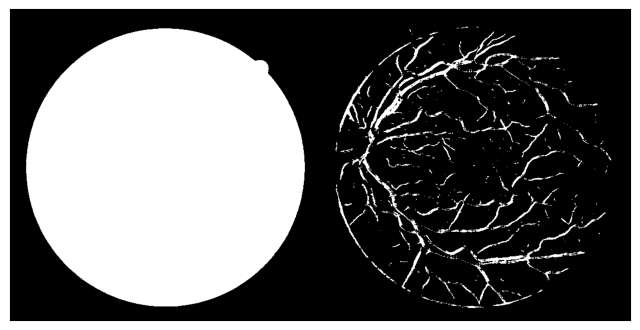

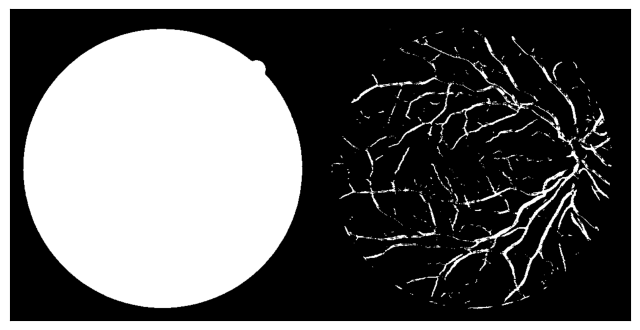

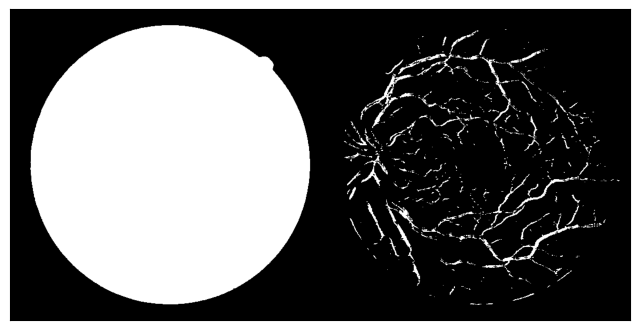

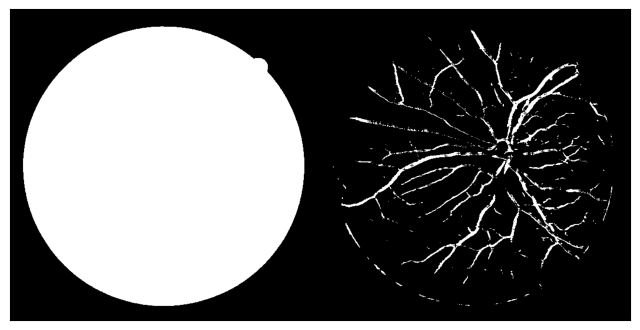

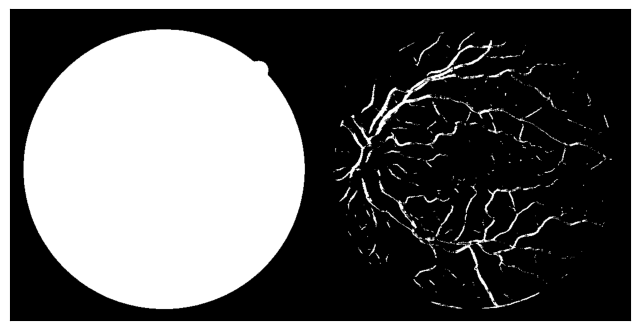

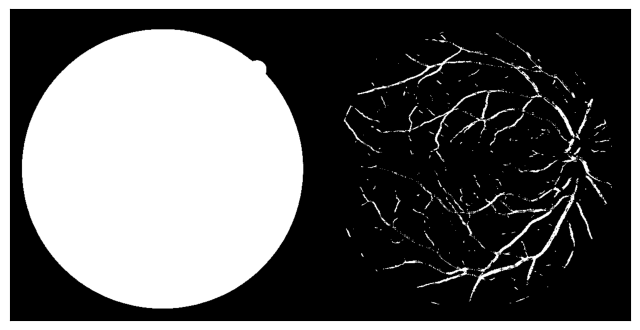

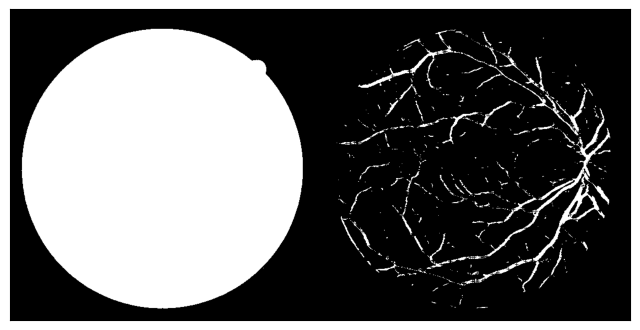

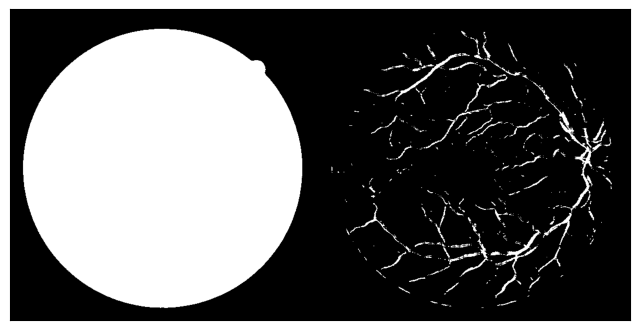

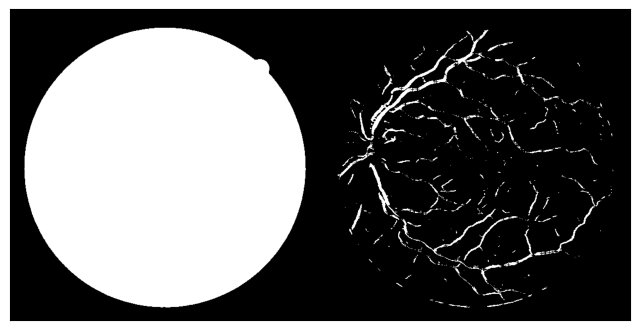

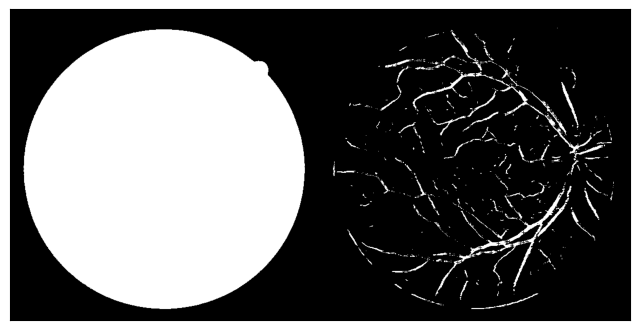

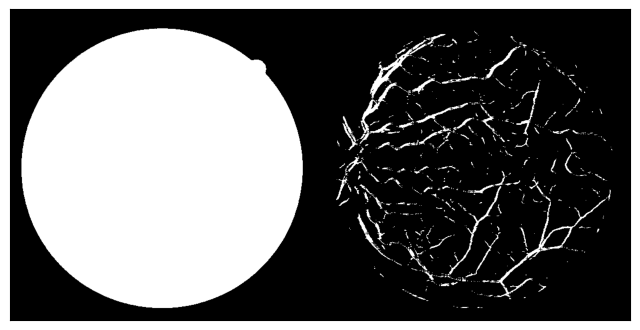

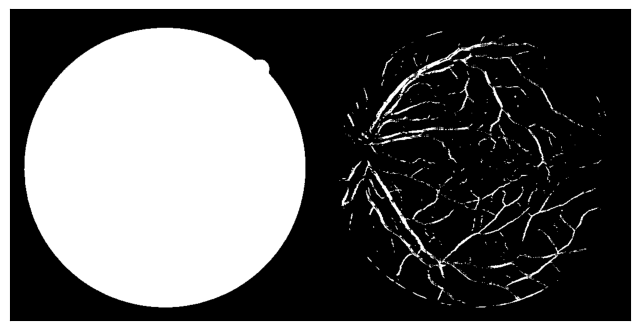

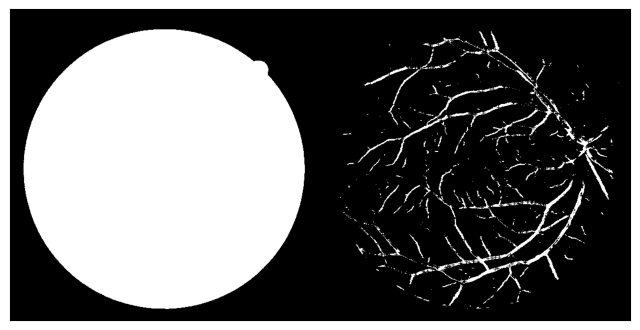

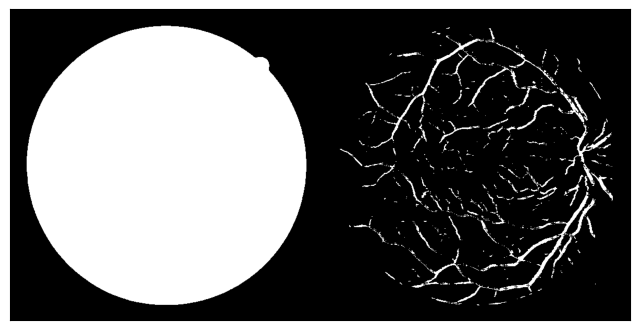

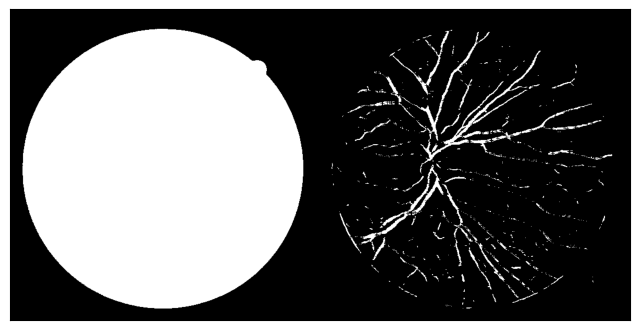

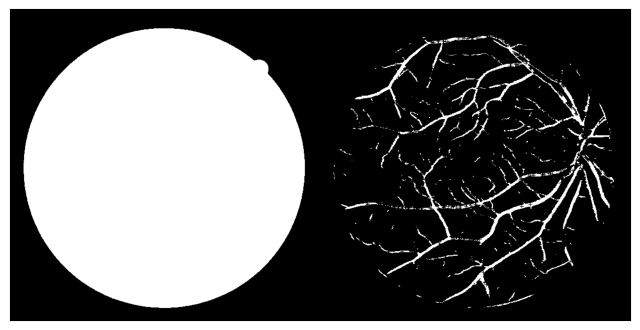

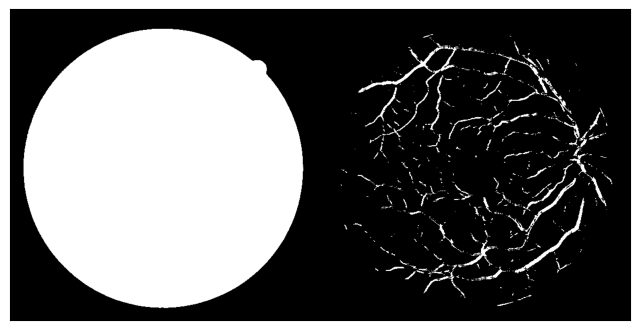

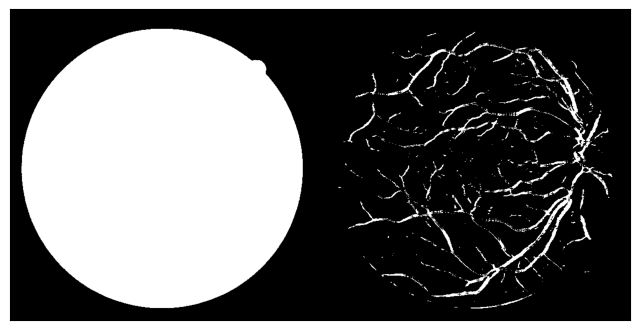

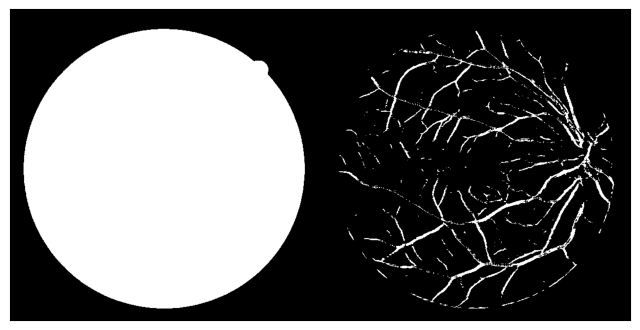

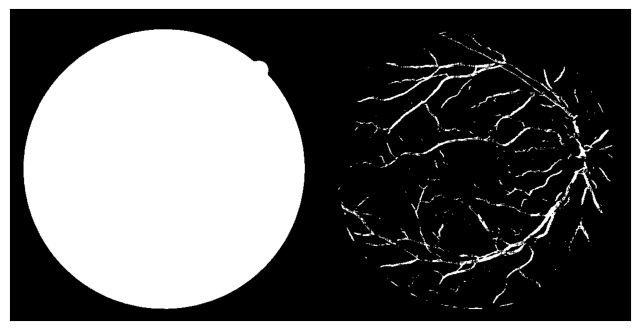

In [43]:
if best_model_state is not None:
    # Reload best model (optional, we already have it in memory)
    best_model = MorphoUNet(in_channels=10).to(device)
    best_model.load_state_dict(best_model_state)
    best_model.eval()
    
    # Show predictions on a few test samples
    print("Displaying predictions on test set:")
    test_model(best_model, threshold=0.5, BZ=True, display_results=True)
else:
    print("No best model to visualize.")

In [44]:
model.eval()
with torch.no_grad():
    inputs, liot, labels = next(iter(pair_dataloader))
    out = torch.sigmoid(model(liot.to(device)))
    print("Pred min/max/mean:", out.min().item(), out.max().item(), out.mean().item())
    print("Label mean (vessel fraction):", labels.mean().item())


Pred min/max/mean: 0.003524970728904009 1.0 0.07509614527225494
Label mean (vessel fraction): 0.061983540654182434


In [56]:
model.eval()
with torch.no_grad():
    for thresh in [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50]:
        dice = test_model(model, threshold=thresh, BZ=True, display_results=False)
        print(f"Threshold {thresh:.2f} → Dice = {dice:.4f}")

Threshold 0.05 → Dice = 0.5549
Threshold 0.10 → Dice = 0.5784
Threshold 0.15 → Dice = 0.5846
Threshold 0.20 → Dice = 0.5855
Threshold 0.25 → Dice = 0.5836
Threshold 0.30 → Dice = 0.5806
Threshold 0.40 → Dice = 0.5716
Threshold 0.50 → Dice = 0.5571


Threshold 0.05 → Dice = 0.2595
Threshold 0.10 → Dice = 0.2172
Threshold 0.15 → Dice = 0.1962

Test set results:
Accuracy:  0.9346
Sensitivity: 0.5302
Dice:      0.5855


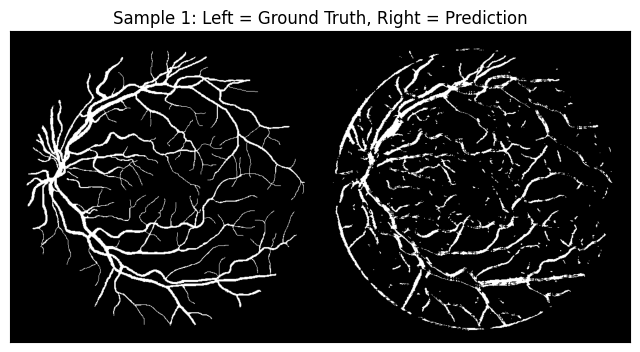

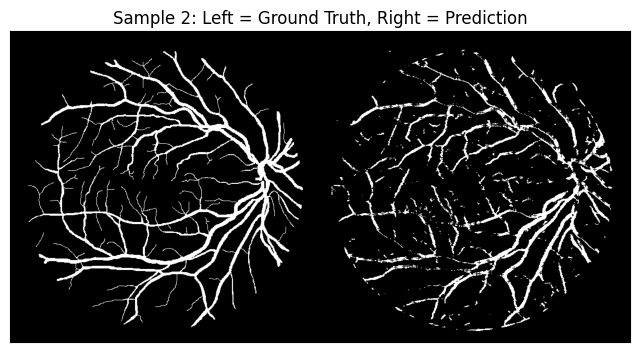

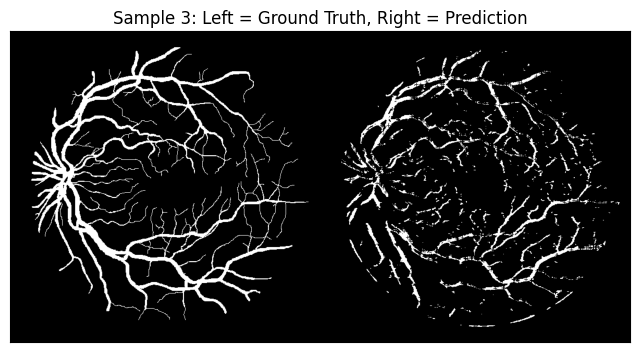

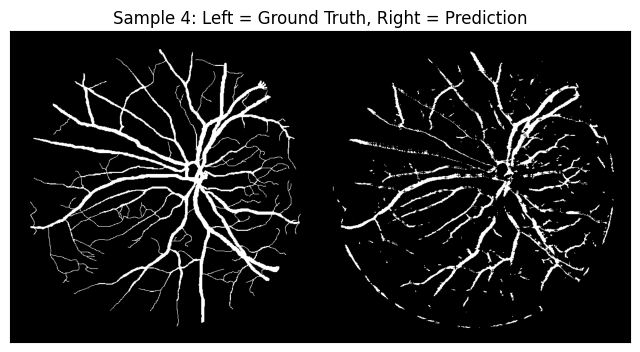

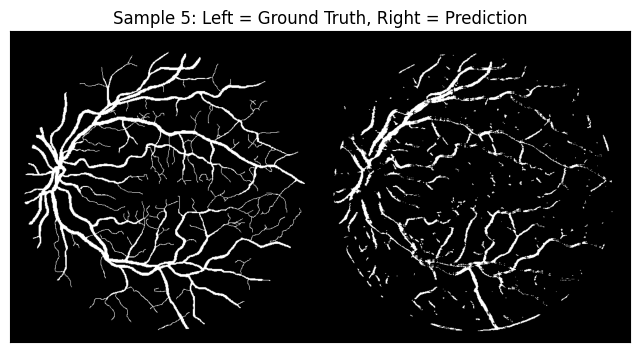

In [57]:
# ==================== Evaluation on Test Set ====================
# This cell evaluates the best model on the test set using accuracy, sensitivity, and Dice coefficient.

import torch
import torchvision
import matplotlib.pyplot as plt

# Load the best model (saved earlier) or reuse the model object
# If you have already trained a model and it's still in memory, you can use that.
# Otherwise, load the saved state dict:


# Define a function to compute all three metrics for a single batch
def compute_metrics(preds, labels):
    # Crop predictions back to original image size (using the global 'original_size' transform)
    preds_cropped = original_size(preds)
    labels_cropped = original_size(labels)
    
    # Binarize predictions (threshold=0.03)
    preds_bin = (preds_cropped > 0.2).float()
    
    # Compute metrics
    acc = accuracy(preds_bin, labels_cropped)
    sens = sensitivity(preds_bin, labels_cropped)
    dice = dice_coef(preds_bin, labels_cropped)
    return acc, sens, dice

# Initialize accumulators
total_acc = 0.0
total_sens = 0.0
total_dice = 0.0
num_samples = 0

# Evaluate on test set
with torch.no_grad():
    for inputs, inputs_LIOT_vp, labels in dataloaders['test']:
        inputs = inputs.to(device)
        inputs_LIOT_vp = inputs_LIOT_vp.to(device)
        labels = labels.to(device)
        
        outputs = model(inputs_LIOT_vp)
        outputs = torch.sigmoid(outputs)
        
        # Post-processing (same as in test_model)
        preds = outputs > 0.2
        preds = remove_circle(inputs, preds, 7, 0.1)
        
        acc, sens, dice = compute_metrics(preds, labels)
        total_acc += acc
        total_sens += sens
        total_dice += dice
        num_samples += 1

# Average metrics over test set
avg_acc = total_acc / num_samples
avg_sens = total_sens / num_samples
avg_dice = total_dice / num_samples

print(f"Test set results:")
print(f"Accuracy:  {avg_acc:.4f}")
print(f"Sensitivity: {avg_sens:.4f}")
print(f"Dice:      {avg_dice:.4f}")

# Optional: Visualize some predictions (as in the test_model function)
for i, (inputs, inputs_LIOT_vp, labels) in enumerate(dataloaders['test']):
    if i >= 5:  # show only first 5 images
        break
    inputs = inputs.to(device)
    inputs_LIOT_vp = inputs_LIOT_vp.to(device)
    labels = labels.to(device)
    
    outputs = model(inputs_LIOT_vp)
    outputs = torch.sigmoid(outputs)
    preds = outputs > 0.2
    preds = remove_circle(inputs, preds, 7, 0.1)
    
    grid = torchvision.utils.make_grid([labels[0], preds[0]]).cpu()
    plt.figure(figsize=(8,8))
    plt.imshow(grid.permute(1,2,0))
    plt.title(f"Sample {i+1}: Left = Ground Truth, Right = Prediction")
    plt.xticks([]); plt.yticks([])
    plt.show()